In [5]:
import pandas as pd
import numpy as np
import proplot as pplt
from matplotlib.lines import Line2D

df = pd.read_csv('./results/seasonal_max_wind_summary.csv')

region_ids = sorted(df['region'].unique())
climate_scenarios = [col for col in df.columns if 'scn' in col]
years = [2030, 2040, 2050]
climate_name = ['SSP245(c)', 'SSP585(c)', 'SSP245(h)','SSP585(h)']
#####
arr = np.load('your_directory/loads/subregion_mask.npz', allow_pickle=True)['id_to_subregion']
arr[:, 1] = [s.replace('_', ' ') for s in arr[:, 1]]
label_list = arr[:, 1].tolist()
label_list = [s.replace('NorthernGrid', 'NG').replace('WestConnect', 'WC') for s in label_list]
del label_list[2]
del label_list[6]

[1.62812914 1.6823146  1.91055276]


/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() 

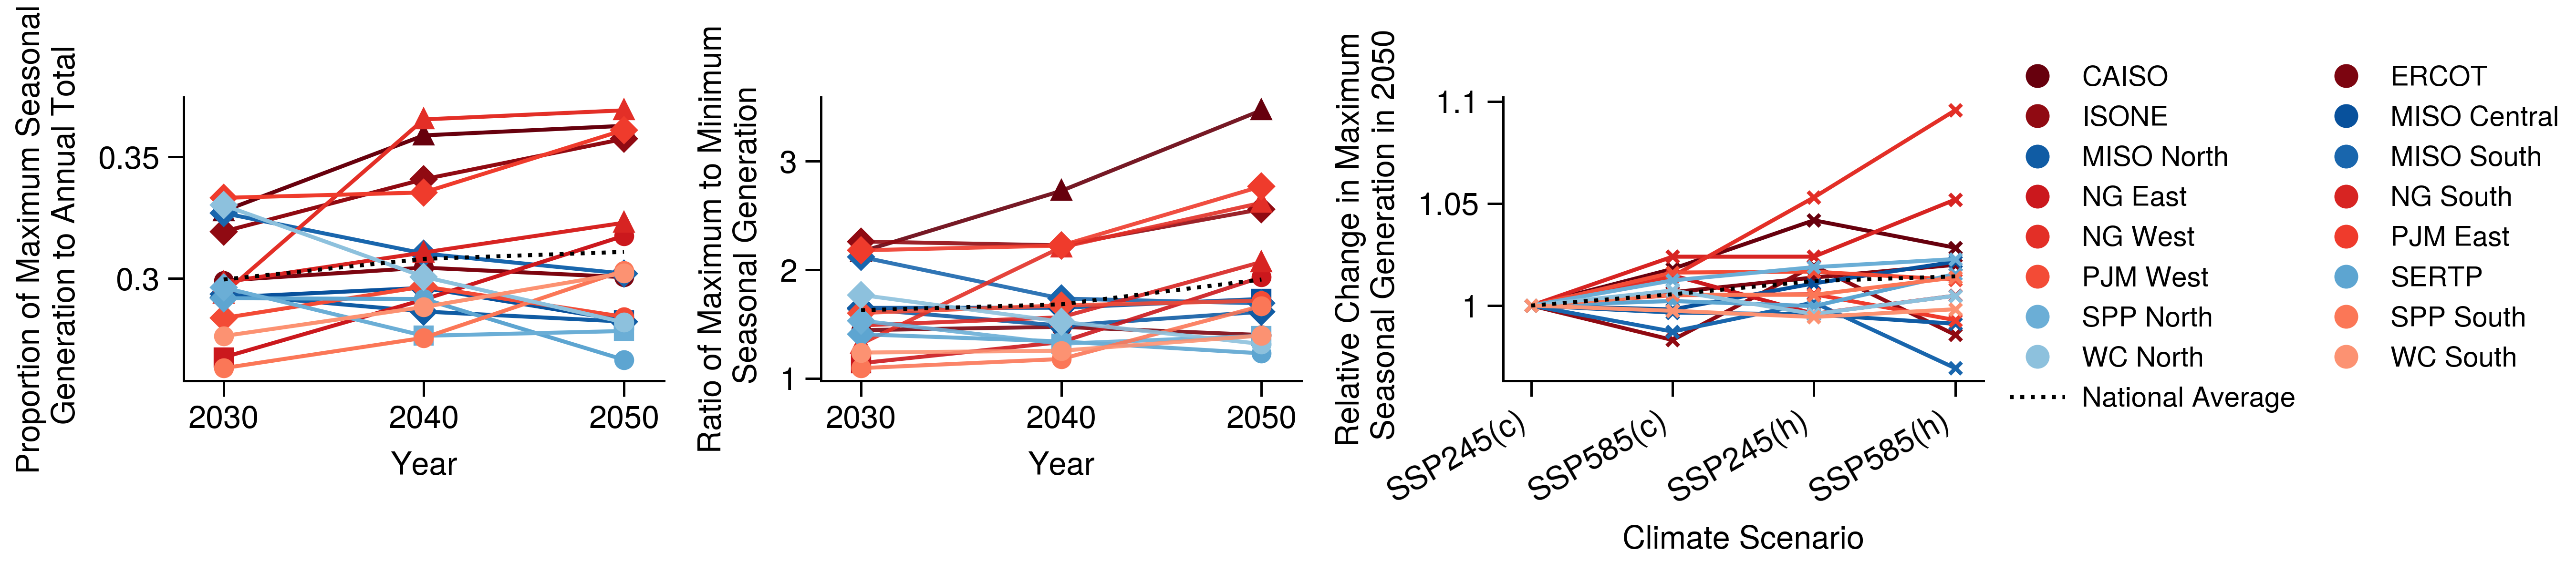

In [6]:
fig, axs = pplt.subplots(nrows=1, ncols=3, figsize=(9, 2), sharey=False, sharex=False,dpi=300)
fig.patch.set_facecolor('white')

cmap_up = pplt.Colormap('Reds_r', N=25)
cmap_down = pplt.Colormap('Blues_r', N=25)

ax = axs[0]
k = 0
x = [0,1,2]
color_array = []
for rid in region_ids:
    df_r = df[df['region'] == rid].sort_values('year')
    max_vals = df_r['max_val'].values
    max_vals_norm = max_vals   # 2030归一化为1
    season_markers = ['o', '^', 's', 'D']  # 0:春, 1:夏, 2:秋, 3:冬
    season_indices = df_r['max_season_idx'].values  # 假设是 ndarray，例如 [1, 0, 3, 2, ...]
    markers = [season_markers[idx] for idx in season_indices]
    trend = max_vals_norm[2] - max_vals_norm[0]
    color = cmap_up(k) if trend > 0 else cmap_down(k)
    color_array.append(color)
    k = k + 1
    for i, year in enumerate(df_r['year'].values):
        ax.plot(i, max_vals_norm[i], marker=markers[i], color=color, ms=4, lw=0)
    ax.plot(x, max_vals_norm, lw=1.0, color=color)
all_mean_vals = []
for rid in region_ids:
    df_r = df[df['region'] == rid].sort_values('year')
    vals = df_r['max_val'].values
    all_mean_vals.append(vals)
avg_vals = np.mean(np.stack(all_mean_vals, axis=0), axis=0)
national_line = ax.plot(x, avg_vals, color='black', lw=1.0, linestyle=':', label='National Avg.')
ax.format(fontsize=8,xlim=(-0.2, 2.2),xticks=[0,1,2],ytickminor=False,xtickminor=False,xticklabels=['2030','2040','2050'],xlabel='Year',
          ylabel='Proportion of Maximum Seasonal\n Generation to Annual Total', grid=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axs[1]
for i, rid in enumerate(region_ids):
    df_r = df[df['region'] == rid].sort_values('year')
    ratios = df_r['max/min_ratio'].values
    season_markers = ['o', '^', 's', 'D']  # 0:春, 1:夏, 2:秋, 3:冬
    season_indices = df_r['max_season_idx'].values  # 假设是 ndarray，例如 [1, 0, 3, 2, ...]
    markers = [season_markers[idx] for idx in season_indices]
    if len(ratios) < 3:
        continue
    trend = ratios[2] - ratios[0]
    color = color_array[i]
    for i, year in enumerate(df_r['year'].values):
        ax.plot(i, ratios[i], marker=markers[i], color=color, ms=4, lw=0)
    ax.plot(x, ratios, lw=1.0, color=color, alpha=0.9)
all_mean_vals = []
for rid in region_ids:
    df_r = df[df['region'] == rid].sort_values('year')
    vals = df_r['max/min_ratio'].values
    all_mean_vals.append(vals)
avg_vals = np.mean(np.stack(all_mean_vals, axis=0), axis=0)
print(avg_vals)
national_line = ax.plot(x, avg_vals, color='black', lw=1.0, linestyle=':', label='National Avg.')
ax.format(fontsize=8,xlim=(-0.2, 2.2),xticks=[0,1,2],ytickminor=False,xtickminor=False,xticklabels=['2030','2040','2050'],
          xlabel='Year',ylabel='Ratio of Maximum to Minimum\n Seasonal Generation', grid=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax = axs[2]
all_mean_vals = []
for i, rid in enumerate(region_ids):
    df_r = df[(df['region'] == rid) & (df['year'] == 2050)]
    if df_r.empty:
        continue
    vals = df_r[climate_scenarios].values.flatten()
    vals_norm = vals / (vals[0] + 1e-6)  # 基准为第一个情景
    all_mean_vals.append(vals_norm)
    color = color_array[i]
    ax.plot(range(len(vals_norm)), vals_norm, marker='x', lw=1.0, markersize=3, color=color)
avg_vals = np.mean(np.stack(all_mean_vals, axis=0), axis=0)
national_line = ax.plot([0,1,2,3], avg_vals, color='black', lw=1.0, linestyle=':', label='National Avg.')
ax.format(xlabel='Climate Scenario', ylabel='Relative Change in Maximum\n Seasonal Generation in 2050',
          xticks=range(len(climate_scenarios)), xticklabels=climate_name,fontsize=8,xlim=(-0.2, 3.2), grid=False,ytickminor=False,xtickminor=False,xrotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
           markeredgecolor='none', markersize=6, label=label)
    for c, label in zip(color_array, label_list)]
legend_handles.append(national_line[0])
label_list.append('National Average')
ax.legend(legend_handles, label_list, ncol=2, loc='right', frame=False, prop={'size': 7}, handlelength=2.0,
    handletextpad=0.6, columnspacing=0.8, borderaxespad=0.3)
fig.savefig("./figs/wind_season_trend.png", bbox_inches='tight', pad_inches=0)